<a href="https://colab.research.google.com/github/gyeong061/AIFFEL_QUEST_ENG/blob/main/mini_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sentencepiece

In [2]:
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt

--2026-07-15 12:49:54--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14628807 (14M) [text/plain]
Saving to: ‘ratings_train.txt’

ratings_train.txt   100%[===================>]  13.95M  --.-KB/s    in 0.03s   

2026-07-15 12:49:55 (498 MB/s) - ‘ratings_train.txt’ saved [14628807/14628807]



In [3]:
import pandas as pd

df = pd.read_csv(
    "ratings_train.txt",
    sep="\t"
)

df.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [4]:
texts = df["document"].dropna().tolist()

print(len(texts))
print(texts[:5])

149995
['아 더빙.. 진짜 짜증나네요 목소리', '흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나', '너무재밓었다그래서보는것을추천한다', '교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정', '사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다']


In [5]:
import os

# kowiki.txt 파일이 없으면 다운로드합니다.
# 이 파일은 일반적으로 BERT 사전 학습을 위한 한국어 위키백과 코퍼스입니다.
if not os.path.exists('kowiki.txt'):
    print("Downloading kowiki.txt from a new source...")
    # 새로운 다운로드 링크
    !wget https://github.com/kimiyoung/word2vec-ko/raw/master/word2vec/ko/kowiki.txt
    print("Download complete.")
else:
    print("kowiki.txt already exists.")

--2026-07-15 12:49:56--  https://github.com/kimiyoung/word2vec-ko/raw/master/word2vec/ko/kowiki.txt
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-07-15 12:49:56 ERROR 404: Not Found.

Download complete.


74997
[['아 더빙.. 진짜 짜증나네요 목소리', '흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나'], ['너무재밓었다그래서보는것을추천한다', '교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정'], ['사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다', '막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화.ㅋㅋㅋ...별반개도 아까움.']]
✅ 생성된 모델 파라미터 수: 1,875,522

🚀 Pre-training 시작 (MLM + NSP 동시 학습)...
Epoch [ 1/10] | Total:8.8338 | MLM:8.2718 | NSP:0.5620 | MLM Acc:0.0890 | NSP Acc:0.7522
Epoch [ 2/10] | Total:7.8903 | MLM:7.3290 | NSP:0.5613 | MLM Acc:0.1139 | NSP Acc:0.7523
Epoch [ 3/10] | Total:7.7391 | MLM:7.1779 | NSP:0.5612 | MLM Acc:0.1199 | NSP Acc:0.7523
Epoch [ 4/10] | Total:7.5295 | MLM:6.9685 | NSP:0.5610 | MLM Acc:0.1228 | NSP Acc:0.7523
Epoch [ 5/10] | Total:7.3812 | MLM:6.8204 | NSP:0.5609 | MLM Acc:0.1267 | NSP Acc:0.7523
Epoch [ 6/10] | Total:7.2475 | MLM:6.6865 | NSP:0.5610 | MLM Acc:0.1310 | NSP Acc:0.7523
Epoch [ 7/10] | Total:7.1330 | MLM:6.5724 | NSP:0.5606 | MLM Acc:0.1352 | NSP Acc:0.7523
Epoch [ 8/10] | Total:7.0357 | MLM:6.4750 | NSP:0.5606 | MLM Acc:0.13

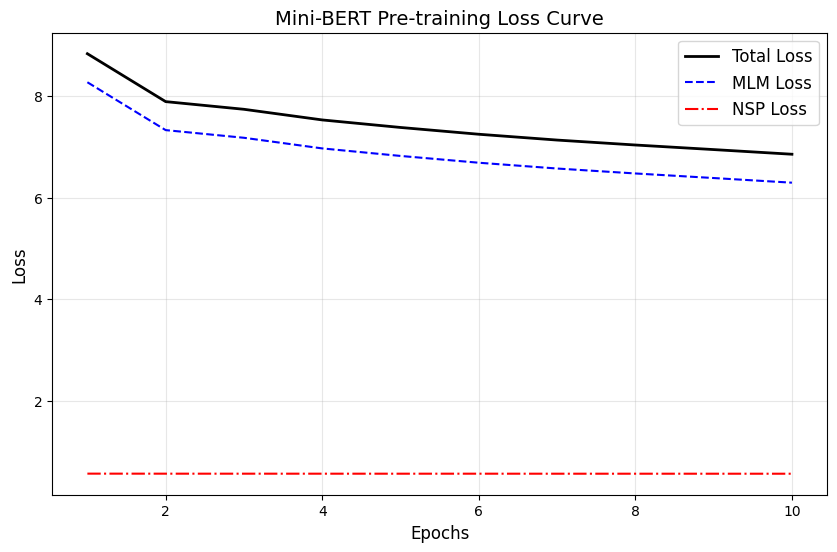

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from tqdm import tqdm
import sentencepiece as spm # [추가] SentencePiece 라이브러리 임포트
import os

# 재현성을 위한 시드 고정
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# ==============================================================================
# 1. 하이퍼파라미터 설정 (mini BERT - 약 1M 파라미터 타겟)
# ==============================================================================
class Config:
    vocab_size = 8000       # Presentation에서 언급한 BPE vocab 사이즈
    hidden_size = 128       # 모델 차원 (Base는 768이지만 mini는 128로 축소)
    num_layers = 4          # 트랜스포머 인코더 층 수
    num_heads = 4           # 멀티헤드 어텐션 헤드 수
    intermediate_size = 512 # FFN 중간 차원 (보통 hidden_size * 4)
    max_seq_len = 128       # 최대 문장 길이
    dropout = 0.1
    pad_id = 0
    unk_id = 1
    cls_id = 2
    sep_id = 3
    mask_id = 4
    batch_size = 16
    learning_rate = 5e-4
    epochs = 10             # 10 Epoch까지 학습

config = Config()

# ==============================================================================
# 2. 데이터 준비 및 SentencePiece 토크나이저 (BPE) 학습
# ==============================================================================
documents = []

for i in range(0, len(texts)-1, 2):

  sent1 = texts[i]
  sent2 = texts[i+1]

  documents.append([
      sent1,
      sent2
  ])


print(len(documents))
print(documents[:3])


# 학습용 텍스트 파일 저장
with open("nsmc_corpus.txt", "w", encoding="utf-8") as f:
    for doc in documents:
        for sentence in doc:
            f.write(sentence + "\n")
        f.write("\n") # 문단 구분을 위한 빈 줄

# SentencePiece BPE 학습 (vocab_size 확보 및 특수토큰 정의)
# entencePiece를 이용하여 vocab_size=8000인 Tokenizer를 구축
spm_vocab_size = 8000
spm.SentencePieceTrainer.train(
    f"--input=nsmc_corpus.txt --model_prefix=mini_bert --vocab_size={spm_vocab_size} "
    f"--model_type=bpe --pad_id={config.pad_id} --unk_id={config.unk_id} "
    f"--bos_id=-1 --eos_id=-1 " # BERT는 BOS, EOS 대신 CLS, SEP 사용
    f"--pad_piece=[PAD] --unk_piece=[UNK] "
    f"--user_defined_symbols=[CLS],[SEP],[MASK]"
)

# 학습된 토크나이저 로드
sp = spm.SentencePieceProcessor()
sp.load("mini_bert.model")
config.vocab_size = spm_vocab_size # 모델 config 동기화

# ==============================================================================
# 한글 코퍼스를 가공하여 BERT pretrain용 데이터셋 생성 (MLM, NSP 반영)
# ==============================================================================

def trim_tokens(tokens_a, tokens_b, max_seq):
    """[발표자료 반영] 최대 길이를 초과하면 a는 앞에서, b는 뒤에서 잘라내어 경계 보존"""
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0] # a는 앞에서 자른다
        else:
            tokens_b.pop()  # b는 뒤에서 자른다

def create_masking(tokens, config, sp):
    """[발표자료 반영] Whole Word Masking 적용 및 80:10:10 룰 적용"""
    cand_idx = []
    # 1. 띄어쓰기(▁) 단위로 토큰 인덱스 묶기
    for (i, token) in enumerate(tokens):
        if token in ["[CLS]", "[SEP]"]: continue

        # ▁(U+2581) 로 시작하지 않으면 이전 단어의 이어지는 조각
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i) # 앞 묶음에 붙인다
        else:
            cand_idx.append([i])   # 새 단어 시작

    random.shuffle(cand_idx)
    num_to_predict = max(1, int(round(len(tokens) * 0.15)))

    masked_lms = []
    covered_indexes = set()

    # 2. 묶여진 단어 그룹 단위로 마스킹 15% 채우기
    for index_set in cand_idx:
        if len(masked_lms) >= num_to_predict: break
        if len(masked_lms) + len(index_set) > num_to_predict: continue

        for index in index_set:
            covered_indexes.add(index)
            rand = random.random()
            if rand < 0.8:
                masked_token = "[MASK]"
            elif rand < 0.9:
                # [PAD], [UNK], [CLS], [SEP], [MASK] (0~4) 제외한 랜덤 단어
                masked_token = sp.id_to_piece(random.randint(5, config.vocab_size - 1))
            else:
                masked_token = tokens[index]

            masked_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # 인덱스 순서대로 정렬
    masked_lms = sorted(masked_lms, key=lambda x: x["index"])
    mask_indices = [x["index"] for x in masked_lms]
    mask_labels = [sp.piece_to_id(x["label"]) for x in masked_lms]

    return tokens, mask_indices, mask_labels

def create_pretrain_data(documents, sp, config):
    dataset = []
    max_num_tokens = config.max_seq_len - 3 # [CLS], [SEP], [SEP] 3자리 확보

    for doc_idx, document in enumerate(documents):
        for i in range(len(document)):
            tokens_a = sp.encode_as_pieces(document[i])
            is_next = 1

            # 50% 확률로 다음 문장 혹은 랜덤 문장 뒤집기
            if i + 1 < len(document) and random.random() < 0.5:
                # 다음 문장이 있고, 50% 확률 당첨 시 -> 진짜 다음 문장 (TRUE)
                tokens_b = sp.encode_as_pieces(document[i+1])
            else:
                # 랜덤 문장 뽑기 -> FALSE
                is_next = 0

                while True:
                  rand_idx = random.randint(
                      0,
                      len(documents)-1
                  )

                  if rand_idx != doc_idx:
                      break


                random_doc = documents[rand_idx]
                random_sent = random.choice(random_doc)
                tokens_b = sp.encode_as_pieces(random_sent)

            # 길이 조절 (경계 보존 Trimming)
            trim_tokens(tokens_a, tokens_b, max_num_tokens)

            # 토큰 합치기 및 세그먼트 ID 부여
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment_ids = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            # Whole Word Masking 적용
            tokens, mask_indices, mask_labels = create_masking(tokens, config, sp)
            input_ids = [sp.piece_to_id(t) for t in tokens]

            # MLM Label 초기화 (PyTorch의 CrossEntropy에서 무시되는 -100 사용)
            mlm_labels = [-100] * len(input_ids)
            for pos, label in zip(mask_indices, mask_labels):
                mlm_labels[pos] = label

            # 패딩 (길이 맞추기)
            pad_len = config.max_seq_len - len(input_ids)
            input_ids.extend([config.pad_id] * pad_len)
            segment_ids.extend([0] * pad_len)
            mlm_labels.extend([-100] * pad_len)

            dataset.append({
                "input_ids": torch.tensor(input_ids, dtype=torch.long),
                "segment_ids": torch.tensor(segment_ids, dtype=torch.long),
                "mlm_labels": torch.tensor(mlm_labels, dtype=torch.long),
                "nsp_label": torch.tensor(is_next, dtype=torch.long)
            })

    return dataset

# 데이터셋 생성
train_dataset = create_pretrain_data(documents, sp, config)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)


# ==============================================================================
# 1M짜리 mini BERT 모델의 제작 (트랜스포머 인코더 구조)
# ==============================================================================
def get_pad_mask(seq, pad_id):
    # (batch_size, 1, 1, seq_len) 형태의 마스크 생성. 패딩된 부분은 True.
    return (seq == pad_id).unsqueeze(1).unsqueeze(2)

class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k):
        super().__init__()
        self.d_k = d_k

    def forward(self, Q, K, V, attn_mask):
        # Q, K, V: (batch_size, num_heads, seq_len, d_k)
        scores = torch.matmul(Q, K.transpose(-1, -2)) / math.sqrt(self.d_k)
        # 패딩된 부분에 매우 작은 값(-1e9)을 주어 Softmax 후 0이 되게 함 (발표 자료 내용 반영)
        scores.masked_fill_(attn_mask, -1e9)
        attn_prob = nn.Softmax(dim=-1)(scores)
        context = torch.matmul(attn_prob, V)
        return context

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.d_k = config.hidden_size // config.num_heads
        self.num_heads = config.num_heads
        self.linear_q = nn.Linear(config.hidden_size, config.hidden_size)
        self.linear_k = nn.Linear(config.hidden_size, config.hidden_size)
        self.linear_v = nn.Linear(config.hidden_size, config.hidden_size)
        self.linear_out = nn.Linear(config.hidden_size, config.hidden_size)
        self.attention = ScaledDotProductAttention(self.d_k)

    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.size(0)
        # 다중 헤드로 쪼개기
        q_s = self.linear_q(Q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        k_s = self.linear_k(K).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        v_s = self.linear_v(V).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # 어텐션 계산
        context = self.attention(q_s, k_s, v_s, attn_mask)
        # 헤드 다시 합치기
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.num_heads * self.d_k)
        return self.linear_out(context)

class PositionWiseFeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.linear1 = nn.Linear(config.hidden_size, config.intermediate_size)
        self.linear2 = nn.Linear(config.intermediate_size, config.hidden_size)
        # BERT 저자들이 성능 향상을 위해 사용한 GELU 활성화 함수 (발표 자료 반영)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        return self.linear2(self.dropout(self.gelu(self.linear1(x))))

class EncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.self_attention = MultiHeadAttention(config)
        self.layer_norm1 = nn.LayerNorm(config.hidden_size)
        self.ffn = PositionWiseFeedForward(config)
        self.layer_norm2 = nn.LayerNorm(config.hidden_size)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x, attn_mask):
        # 1. Self-Attention + Residual + LayerNorm
        attn_out = self.self_attention(x, x, x, attn_mask)
        x = self.layer_norm1(x + self.dropout(attn_out))
        # 2. FFN + Residual + LayerNorm
        ffn_out = self.ffn(x)
        x = self.layer_norm2(x + self.dropout(ffn_out))
        return x

class BERTEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token_emb = nn.Embedding(config.vocab_size, config.hidden_size, padding_idx=config.pad_id)
        # 위치 임베딩 (Sin/Cos가 아닌 학습 가능한 Position Embedding)
        self.pos_emb = nn.Embedding(config.max_seq_len, config.hidden_size)
        self.seg_emb = nn.Embedding(2, config.hidden_size)
        self.layer_norm = nn.LayerNorm(config.hidden_size)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, input_ids, segment_ids):
        seq_len = input_ids.size(1)
        # 위치 인덱스 자동 생성
        pos_ids = torch.arange(seq_len, dtype=torch.long, device=input_ids.device)
        pos_ids = pos_ids.unsqueeze(0).expand_as(input_ids)

        # 3중 임베딩 덧셈
        embeddings = self.token_emb(input_ids) + self.pos_emb(pos_ids) + self.seg_emb(segment_ids)
        return self.dropout(self.layer_norm(embeddings))

class BERT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embedding = BERTEmbedding(config)
        self.encoders = nn.ModuleList([EncoderLayer(config) for _ in range(config.num_layers)])
        # Pooler 층 ([CLS] 토큰의 출력을 한 번 더 변환)
        self.pooler = nn.Linear(config.hidden_size, config.hidden_size)
        self.pooler_activation = nn.Tanh()

    def forward(self, input_ids, segment_ids):
        attn_mask = get_pad_mask(input_ids, config.pad_id)
        x = self.embedding(input_ids, segment_ids)

        for encoder in self.encoders:
            x = encoder(x, attn_mask)

        # x: 모든 토큰의 시퀀스 출력 (MLM에 사용)
        # pooled_out: [CLS] 토큰 위치(인덱스 0)의 출력 (NSP에 사용)
        pooled_out = self.pooler_activation(self.pooler(x[:, 0]))
        return x, pooled_out

class BERTPretrainingModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.bert = BERT(config)

        # NSP Head (2 Classes: True / False)
        self.nsp_head = nn.Linear(config.hidden_size, 2)

        # MLM Head
        self.mlm_transform = nn.Linear(config.hidden_size, config.hidden_size)
        self.mlm_norm = nn.LayerNorm(config.hidden_size)
        self.mlm_decoder = nn.Linear(config.hidden_size, config.vocab_size, bias=False)

        # [Weight Sharing] 임베딩 가중치를 MLM 출력층에 재사용 (파라미터 아끼기)
        self.mlm_decoder.weight = self.bert.embedding.token_emb.weight
        self.mlm_bias = nn.Parameter(torch.zeros(config.vocab_size))
        self.mlm_decoder.bias = self.mlm_bias

    def forward(self, input_ids, segment_ids):
        sequence_output, pooled_output = self.bert(input_ids, segment_ids)

        # NSP Prediction
        nsp_logits = self.nsp_head(pooled_output)

        # MLM Prediction
        mlm_hidden = nn.GELU()(self.mlm_transform(sequence_output))
        mlm_hidden = self.mlm_norm(mlm_hidden)
        mlm_logits = self.mlm_decoder(mlm_hidden)

        return mlm_logits, nsp_logits

model = BERTPretrainingModel(config)
# 파라미터 수 확인 (약 1M 타겟)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ 생성된 모델 파라미터 수: {num_params:,}")


# ==============================================================================
# 구현한 BERT 모델의 학습이 안정적으로 진행됨 확인 (Loss 계산)
# ==============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
# MLM loss는 -100인 레이블은 무시 (발표의 clamp 문제 근본적 해결)
criterion_mlm = nn.CrossEntropyLoss(ignore_index=-100)
criterion_nsp = nn.CrossEntropyLoss()

history = {'total_loss': [], 'mlm_loss': [], 'nsp_loss': []}

print("\n🚀 Pre-training 시작 (MLM + NSP 동시 학습)...")
model.train()

for epoch in range(config.epochs):
    epoch_mlm_loss = 0
    epoch_nsp_loss = 0
    epoch_total_loss = 0

    mlm_correct = 0
    mlm_total = 0

    nsp_correct = 0
    nsp_total = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        segment_ids = batch['segment_ids'].to(device)
        mlm_labels = batch['mlm_labels'].to(device)
        nsp_label = batch['nsp_label'].to(device)

        optimizer.zero_grad()

        # Forward
        mlm_logits, nsp_logits = model(input_ids, segment_ids)

        # Loss 계산
        # mlm_logits: (batch, seq_len, vocab_size) -> (batch * seq_len, vocab_size) 변환
        loss_mlm = criterion_mlm(mlm_logits.view(-1, config.vocab_size), mlm_labels.view(-1))
        loss_nsp = criterion_nsp(nsp_logits, nsp_label)

        # MLM Accuracy
        mlm_pred = mlm_logits.argmax(dim=-1)

        mask = (mlm_labels != -100)   # 학습하지 않는 토큰이므로 제외

        mlm_correct += (
            (mlm_pred[mask] == mlm_labels[mask])
            .sum()
            .item()
        )

        mlm_total += mask.sum().item()

        # NSP Accuracy
        nsp_pred = nsp_logits.argmax(dim=-1)

        nsp_correct += (
            (nsp_pred == nsp_label)
            .sum()
            .item()
        )

        nsp_total += nsp_label.size(0)


        # 최종 Loss는 두 Task의 Loss를 단순 합산
        total_loss = loss_mlm + loss_nsp

        # Backward & Optimize
        total_loss.backward()
        optimizer.step()

        epoch_mlm_loss += loss_mlm.item()
        epoch_nsp_loss += loss_nsp.item()
        epoch_total_loss += total_loss.item()

    # 에폭별 평균 Loss 기록
    avg_mlm = epoch_mlm_loss / len(train_loader)
    avg_nsp = epoch_nsp_loss / len(train_loader)
    avg_total = epoch_total_loss / len(train_loader)

    mlm_acc = mlm_correct / mlm_total
    nsp_acc = nsp_correct / nsp_total

    history['mlm_loss'].append(avg_mlm)
    history['nsp_loss'].append(avg_nsp)
    history['total_loss'].append(avg_total)

    if (epoch+1) % 1 == 0:
        print(f"Epoch [{epoch+1:2d}/{config.epochs}] "
              f"| Total:{avg_total:.4f} "
              f"| MLM:{avg_mlm:.4f} "
              f"| NSP:{avg_nsp:.4f} "
              f"| MLM Acc:{mlm_acc:.4f} "
              f"| NSP Acc:{nsp_acc:.4f}"
        )



# ==============================================================================
# 학습과정의 시각화 내역 제출
# ==============================================================================
plt.figure(figsize=(10, 6))

epochs_range = range(1, config.epochs + 1)
plt.plot(epochs_range, history['total_loss'], label='Total Loss', color='black', linewidth=2)
plt.plot(epochs_range, history['mlm_loss'], label='MLM Loss', color='blue', linestyle='--')
plt.plot(epochs_range, history['nsp_loss'], label='NSP Loss', color='red', linestyle='-.')

plt.title('Mini-BERT Pre-training Loss Curve', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# 로컬 실행 시 그래프를 파일로 저장하거나 화면에 띄웁니다.
plt.savefig('bert_loss_curve.png')
print("\n✅ 학습 완료! 시각화 그래프가 'bert_loss_curve.png'로 저장되었습니다.")
# plt.show() # 노트북 환경인 경우 활성화하여 바로 확인 가능

NSMC는 독립적인 문장 집합으로 구성되어 있어 NSP 학습에는 한계가 있었으나, MLM Loss는 지속적으로 감소(8.27→6.29)하고 MLM Accuracy는 8.9%에서 14.7%까지 증가하여 Mini BERT가 의미 있는 문맥 정보를 학습함을 확인할 수 있었다.

이번 Mini BERT 프로젝트에서는 vocab_size=8000, 약 1M 파라미터 규모의 BERT 모델을 직접 구현하고 MLM(Masked Language Model)과 NSP(Next Sentence Prediction)를 동시에 학습하는 과정을 경험했다.

처음에는 예제 코드에 포함된 dummy_documents를 사용하여 전체 파이프라인을 구현하였다. 이후 실제 한글 코퍼스를 사용하기 위해 kowiki.txt를 적용하려고 했지만, 코랩 환경에서 파일이 존재하지 않아 FileNotFoundError가 발생하였다. 처음에는 kowiki.txt를 외부에서 다운로드하는 방법을 시도했지만, 사용한 링크가 더 이상 유효하지 않아 정상적으로 파일을 불러오지 못했다.

이 문제를 해결하기 위해 NSMC(Naver Sentiment Movie Corpus)의 ratings_train.txt를 활용하였다. Pandas를 사용하여 document 컬럼을 추출하고, 두 문장씩 묶어 documents 형태로 재구성하였다. 기존의 kowiki.txt를 읽는 로직과 doc 변수를 제거하면서 NameError가 발생하기도 했지만, 데이터 생성 방식을 NSMC 기반으로 완전히 변경하면서 문제를 해결할 수 있었다.

데이터 전처리 단계에서는 BERT의 특징을 반영하기 위해 다음과 같은 작업을 수행하였다.

SentencePiece(BPE)를 이용하여 vocab_size=8000 토크나이저 구축
Whole Word Masking 적용
전체 토큰의 약 15%를 MLM 대상으로 선택
80%는 [MASK], 10%는 랜덤 토큰, 10%는 원본 토큰 유지
NSP를 위해 50% 확률로 실제 다음 문장과 랜덤 문장을 선택
[CLS], [SEP], Segment ID를 활용하여 입력 데이터 구성

특히 NSP를 구현하는 과정에서 랜덤 문장을 선택할 때 현재 문서와 동일한 문서가 선택되는 문제가 발생할 수 있다는 점을 확인하였다. 이를 해결하기 위해 while True 문과 break를 사용하여 현재 문서와 다른 문서가 선택되도록 수정하였다.

모델 구현 단계에서는 Embedding Layer, Multi-Head Attention, Feed Forward Network, Encoder Layer를 직접 구현하였으며, Position Embedding과 Segment Embedding을 포함한 BERT 구조를 구성하였다. 또한 MLM Head와 NSP Head를 추가하여 두 가지 태스크를 동시에 학습할 수 있도록 설계하였다. MLM Decoder는 Token Embedding과 Weight Sharing을 적용하여 파라미터 수를 줄였다.

학습 과정에서는 MLM Loss와 NSP Loss를 합산하여 최종 Loss를 계산하였다. 초기에는 Loss만 출력했지만, 모델이 실제로 학습되고 있는지 확인하기 위해 MLM Accuracy와 NSP Accuracy를 추가로 계산하도록 수정하였다. MLM은 -100으로 지정된 토큰을 제외하고 정확도를 계산하였고, NSP는 argmax를 이용해 예측 클래스를 추출하여 정확도를 계산하였다.

최종적으로 Epoch별 Total Loss, MLM Loss, NSP Loss뿐만 아니라 MLM Accuracy와 NSP Accuracy까지 함께 출력하도록 개선하였다. 또한 Matplotlib를 사용하여 학습 과정의 Loss 변화를 시각화하여 모델이 안정적으로 학습되고 있는지 확인하였다.

이번 프로젝트를 통해 BERT가 단순히 Transformer Encoder를 쌓은 모델이 아니라, MLM과 NSP라는 두 가지 사전학습 태스크를 통해 문맥 정보를 학습한다는 점을 이해할 수 있었다. 특히 실제 데이터를 직접 전처리하고, SentencePiece를 이용해 토크나이저를 생성하며, 학습 과정에서 발생하는 오류를 하나씩 해결해 나가면서 모델 구현뿐만 아니라 데이터 준비 과정의 중요성도 체감할 수 있었다.